Mounting my Google drive

# Customer Segmentation Analysis

## Oasis Infobyte Data Analytics Internship

### Task 2: Customer Segmentation Analysis

**Author:** Abenet Asnake Tesfaye

## Objective

The objective of this project is to segment customers based on their annual income and spending score using K-Means Clustering. This analysis helps businesses identify different customer groups and develop targeted marketing strategies.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

plt.style.use('default')
sns.set_style("whitegrid")

# Loading the data set

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Loading the data set from google drive



In [3]:
file_path = "/content/drive/MyDrive/Work Document/OASIS INFOBYTE/DataAnalytics-L1-CustomerSegmentation/Mall_Customers.csv"
# Added encoding parameter to handle non-utf-8 characters
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Missing Values & Duplicates

In [4]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

Missing Values
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Records
0


# Statistical Summary

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Exploratory Data Analysis (EDA)

Gender Distribution

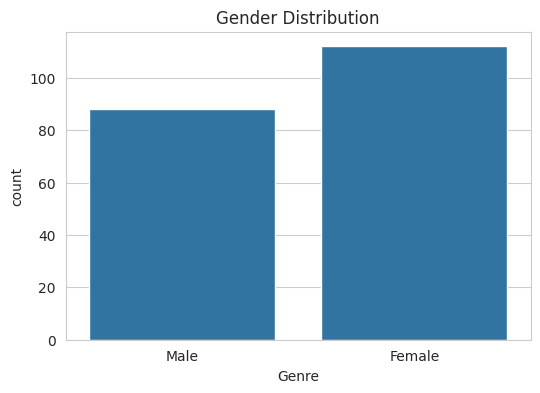

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Genre', data=df)

plt.title('Gender Distribution')

plt.savefig('gender_distribution.png')

plt.show()

** Age Distribution

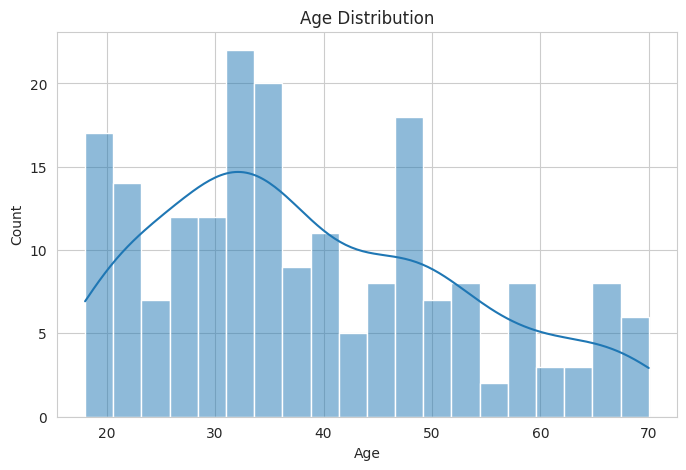

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')

plt.savefig('age_distribution.png')

plt.show()

**Annual Income Distribution

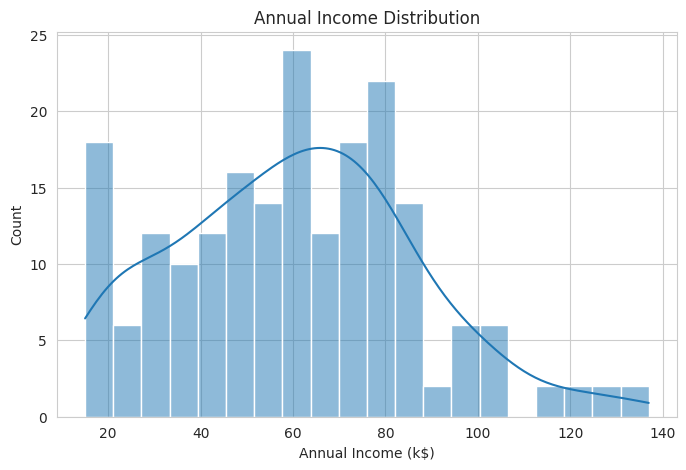

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'],
             bins=20,
             kde=True)

plt.title('Annual Income Distribution')

plt.savefig('income_distribution.png')

plt.show()

Spending Score Distribution

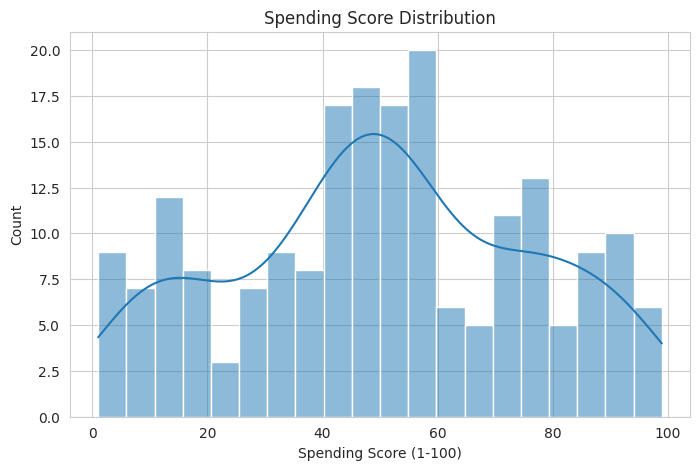

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True
)

plt.title('Spending Score Distribution')

plt.savefig('spending_distribution.png')

plt.show()

Correlation Heatmap

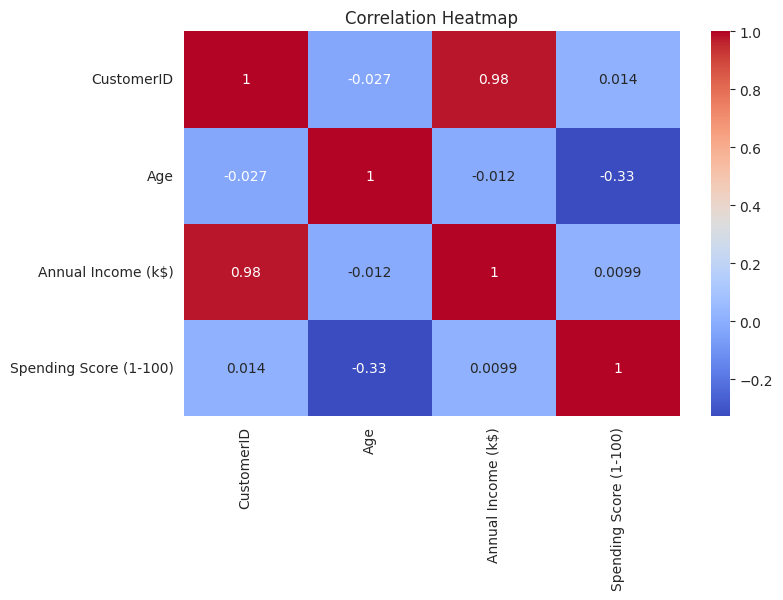

In [11]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png')

plt.show()

##**Customer Segmentation**

**Select Features**

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X)


     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


**Elbow Method**

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

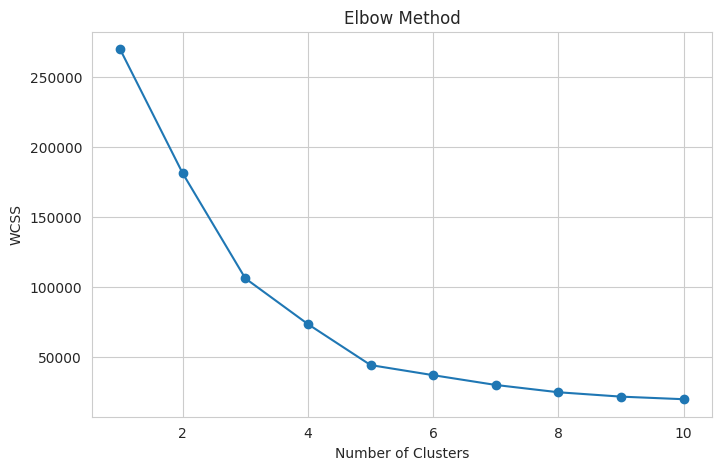

In [15]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

    #pilot Elobow method
    plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.savefig('elbow_method.png')

plt.show()

**Apply K-Means**

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)
# display the clustered dataset
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


**Customer Segments Visualization**

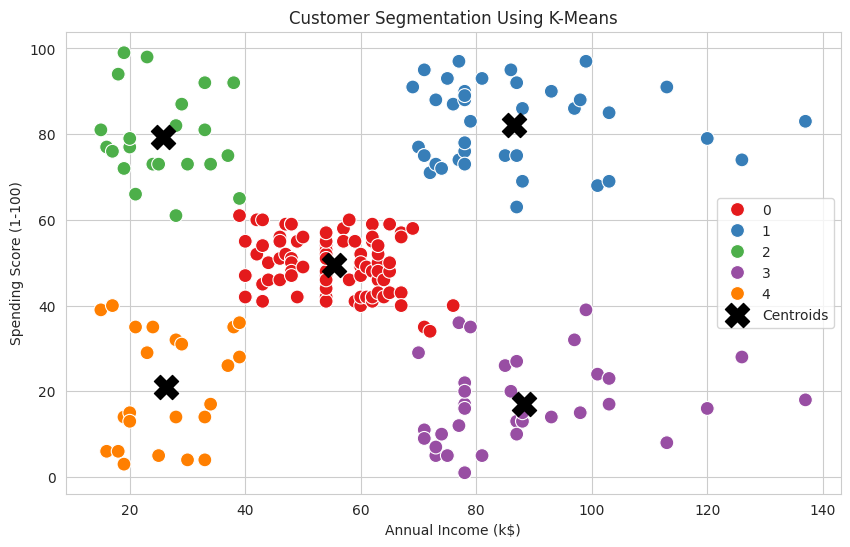

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title(
    'Customer Segmentation Using K-Means'
)

plt.legend()

plt.savefig('customer_segments.png')

plt.show()

**Cluster Summary**

In [19]:
df.groupby('Cluster').mean(
numeric_only=True
)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


Key Findings

1. Five customer segments were identified.

2. High Income High Spending customers are premium customers.

3. High Income Low Spending customers have potential for targeted marketing.

4. Low Income High Spending customers show growth opportunities.

5. Low Income Low Spending customers require cost-effective strategies.

6. Customer behavior differs significantly across segments.

Business Recommendations
1. Develop loyalty programs for premium customers.

2. Provide personalized promotions.

3. Increase engagement of inactive customers.

4. Improve customer retention strategies.

5. Use segmentation for targeted marketing campaigns.

6. Allocate marketing budgets according to customer value.

#